<a href="https://colab.research.google.com/github/viaamanda/Machine-Learning/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import pandas as dataframe
import string
import nltk
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import collections
import sys
import os
import numpy
import seaborn as sns
import csv
from collections import OrderedDict
from nltk.tokenize import word_tokenize
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from IPython.display import display
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from pylab import figure, axes, pie, title, show
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
github_csv_url = 'https://raw.githubusercontent.com/prlputriih/machine_learning/refs/heads/main/mybca_reviews.csv' # Example: make sure this is a RAW GitHub CSV link, not a GitHub page link

try:
    # Ensure pandas is imported (e.g., in an earlier cell: import pandas as pd)
    df_github = pd.read_csv(github_csv_url)
    print("CSV loaded successfully from GitHub!")
    display(df_github.head())
except NameError as e:
    print(f"Error: {e}. Please ensure 'import pandas as pd' has been executed.")
except Exception as e:
    print(f"Error loading CSV from GitHub: {e}")
    print("Please ensure the URL is a direct raw link to the CSV file (e.g., it starts with raw.githubusercontent.com).")

CSV loaded successfully from GitHub!


,rating,review
0,1,servernya tolong di benerin ini transaksi gua ...
1,1,TF seabank ke bca ga masuk masuk udah dua Minggu
2,1,ngebug terussss
3,1,"parahhhh, gagal terima otp padahal pulsa utama..."
4,1,jelek bener gangguan mulu


In [ ]:
df_github = df_github.drop(columns=['rating']) # Replace 'column1', 'column2' with the actual column names you want to drop
display(df_github.head())

,review
0,servernya tolong di benerin ini transaksi gua ...
1,TF seabank ke bca ga masuk masuk udah dua Minggu
2,ngebug terussss
3,"parahhhh, gagal terima otp padahal pulsa utama..."
4,jelek bener gangguan mulu


### Pembersihan Data

In [ ]:

print('Missing values before cleaning:')
print(df_github.isnull().sum())

Missing values before cleaning:
review    0
dtype: int64


In [ ]:
print(f"Number of duplicate reviews before cleaning: {df_github.duplicated().sum()}")
df_github.drop_duplicates(inplace=True)
print(f"Number of duplicate reviews after cleaning: {df_github.duplicated().sum()}")
print(f"DataFrame shape after removing duplicates: {df_github.shape}")

Number of duplicate reviews before cleaning: 19
Number of duplicate reviews after cleaning: 0
DataFrame shape after removing duplicates: (2589, 1)


In [ ]:
# Convert text to lowercase
df_github['review'] = df_github['review'].str.lower()

# Remove punctuation
df_github['review'] = df_github['review'].str.replace(r'[^\w\s]', '', regex=True)

# Remove numbers
df_github['review'] = df_github['review'].str.replace(r'\d+', '', regex=True)

display(df_github.head())

,review
0,servernya tolong di benerin ini transaksi gua ...
1,tf seabank ke bca ga masuk masuk udah dua minggu
2,ngebug terussss
3,parahhhh gagal terima otp padahal pulsa utama ...
4,jelek bener gangguan mulu


In [ ]:
print('Missing values after cleaning:')
print(df_github.isnull().sum())

Missing values after cleaning:
review    0
dtype: int64


In [ ]:
import nltk
nltk.download('wordnet') # Tetap diunduh karena mungkin digunakan nanti, meskipun WordNetLemmatizer tidak digunakan untuk Bahasa Indonesia
nltk.download('omw-1.4')

import re

# Kamus singkatan/slang umum Bahasa Indonesia
# Ini dapat diperluas berdasarkan kebutuhan spesifik dataset
abbreviation_map = {
    # --- Kata Ganti & Entitas ---
    'gua': 'saya', 'gue': 'saya', 'gw': 'saya', 'aku': 'saya', 'aq': 'saya', 'user': 'pengguna', 'ak':'saya',
    'bcaku': 'mybca', 'my bca': 'mybca', 'bca mobile': 'mybca', 'mbca': 'mybca',
    'costumer': 'pelanggan', 'customer': 'pelanggan', 'cs': 'customer service',
    'update': 'perbaharui', 'up': 'perbaharui', 'updt': 'perbaharui',
    'error': 'kesalahan', 'err': 'kesalahan', 'eror': 'kesalahan',
    'biometrix': 'biometri', 'biometrik': 'biometri',
    'maintenance': 'perbaikan', 'maint': 'perbaikan', 'maintn': 'perbaikan',
    'call': 'telepon', 'telp': 'telepon', 'telpon': 'telepon', 'servernya': 'server',
    'up': 'update', 'updt': 'update',
    'adduh': 'aduh', 'duh': 'aduh', 'aduuh': 'aduh', 'aduhh': 'aduh',
    'ahir':'akhir', 'aktip':'aktif', 'log in': 'masuk', 'login': 'masuk',

    # --- Istilah Aplikasi & Bank ---
    'apk': 'aplikasi', 'app': 'aplikasi', 'aps': 'aplikasi', 'apknya': 'aplikasi',
    'mbanking': 'mobile banking', 'ebanking': 'mobile banking', 'm banking': 'mobile banking',
    'tf': 'transfer', 'trf': 'transfer', 'qris': 'qris',
    'rek': 'rekening', 'finasial': 'finansial', 'poto': 'foto', 'develover': 'developer', 'op':'otp',

    # --- Negasi ---
    'ga': 'tidak', 'gak': 'tidak', 'ngga': 'tidak', 'gk': 'tidak', 'g': 'tidak', 'tdk': 'tidak',
    'tida': 'tidak', 'gada': 'tidak ada', 'blm': 'belum', 'gamasuk': 'tidak masuk',
    'nda': 'tidak', 'ndak': 'tidak',

    # --- Intensifier (Kata Keterangan) ---
    'bet': 'sangat', 'bgt': 'sangat', 'banget': 'sangat', 'bener': 'sangat', 'parah': 'sangat',

    # --- Typo, Slang, & Request User ---
    'timbang': 'banding', 'urgent': 'desak', 'negri': 'negeri', 'nmr': 'nomor', 'nomer': 'nomor',
    'riber': 'rumit', 'ribet': 'rumit', 'ribett': 'rumit', 'repot': 'rumit',
    'benerin': 'perbaiki', 'nyalahin': 'menyalahkan', 'bermasalh': 'bermasalah',
    'telkoel': 'telkomsel', 'telko': 'telkomsel', 'yg': 'yang', 'si': 'sih', 'woi': 'hei', 'woy': 'hei',
    'udah': 'sudah', 'udh': 'sudah', 'uda': 'sudah', 'dah': 'sudah', 'sebelumnyauda': 'sebelumnya sudah',
    'jd': 'jadi', 'trs': 'terus', 'trus': 'terus', 'mulu': 'terus',
    'sm': 'sama', 'dr': 'dari', 'utk': 'untuk', 'kayak': 'seperti',
    'gmn': 'bagaimana', 'gimana': 'bagaimana', 'gimna': 'bagaimana', 'gimanasih': 'bagaimana sih',
    'klo': 'kalau', 'aja': 'saja', 'dlm': 'dalam', 'bikin': 'membuat', 'krn': 'karena',
    'dgn': 'dengan', 'lg': 'lagi', 'lgi': 'lagi', 'tp': 'tapi', 'mau': 'akan',
    'tau': 'tahu', 'sempet': 'sempat', 'milih': 'memilih', 'ngetik': 'mengetik', 'ngabisin': 'menghabiskan',
    'berjamjam': 'berjam jam', 'nungguin': 'menunggu', 'nunggu': 'menunggu',
    'mala': 'malah', 'bgs': 'bagus', 'tambahin': 'tambahkan',
    'ko': 'kok', 'koq': 'kok', 'emang': 'memang', 'kesini': 'ke sini', 'bs': 'bisa',
    'aktifin': 'aktifkan', 'ngaktifin': 'mengaktifkan', 'matiin': 'matikan',
    'telp': 'telepon', 'cm': 'cuma', 'lgs': 'langsung', 'y': 'ya', 'knpa': 'kenapa',
    'kmaren': 'kemarin', 'tetep': 'tetap', 'kesedot': 'tersedot',
    'ttp': 'tetap',
    'jls': 'jelas', 'jlsh': 'jelas',
    'lelet': 'lambat', 'hr': 'hari', 'pake': 'pakai', 'prihal': 'perihal', 'baharu': 'baru', 'lot': 'slot', 'lotnya': 'slot',

    # --- Kasus Imbuhan Spesifik ---
    'verivikaisnya': 'verifikasi', 'verivikasi': 'verifikasi', 'verifikasinya': 'verifikasi',
    'aplikasinya': 'aplikasi', 'prosesnya': 'proses', 'servernya': 'server',
    'fiturnya': 'fitur', 'updatenya': 'perbarui', 'aplikasinya': 'aplikasi', 'akunnya': 'akun',
    'loadingnya': 'memuat', 'otpnya': 'kode otp', 'loginnya': 'masuk', 'mbankingnya': 'mobile banking'
}

# Fungsi untuk normalisasi teks (ekspansi singkatan dan pengurangan pengulangan karakter)
def normalize_text(text):
    if isinstance(text, str):
        # 1. Ekspansi singkatan
        words = text.split()
        expanded_words = [abbreviation_map.get(word, word) for word in words]
        normalized_abbreviations_text = ' '.join(expanded_words)

        # 2. Pengurangan pengulangan karakter berlebihan

        final_normalized_text = re.sub(r'(.)\1{2,}', r'\1', normalized_abbreviations_text)

        return final_normalized_text
    return text

# Aplikasikan fungsi normalisasi ke kolom 'review'
df_github['review_normalized'] = df_github['review'].apply(normalize_text)

display(df_github.head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,review,review_normalized
0,servernya tolong di benerin ini transaksi gua ...,server tolong di perbaiki ini transaksi saya k...
1,tf seabank ke bca ga masuk masuk udah dua minggu,transfer seabank ke bca tidak masuk masuk suda...
2,ngebug terussss,ngebug terus
3,parahhhh gagal terima otp padahal pulsa utama ...,parah gagal terima otp padahal pulsa utama sud...
4,jelek bener gangguan mulu,jelek sangat gangguan terus


### Stemming Teks


In [ ]:
# Inisialisasi Stemmer Sastrawi untuk Bahasa Indonesia
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi untuk melakukan stemming
def stem_text(text):
    if isinstance(text, str):
        return stemmer.stem(text)
    return text

# Aplikasikan fungsi stemming ke kolom 'review_normalized'
df_github['review_stemmed'] = df_github['review_normalized'].apply(stem_text)

# Tampilkan beberapa baris pertama dengan kolom baru
display(df_github[['review_normalized', 'review_stemmed']].head())

,review_normalized,review_stemmed
0,server tolong di perbaiki ini transaksi saya k...,server tolong di baik ini transaksi saya kok p...
1,transfer seabank ke bca tidak masuk masuk suda...,transfer seabank ke bca tidak masuk masuk suda...
2,ngebug terus,ngebug terus
3,parah gagal terima otp padahal pulsa utama sud...,parah gagal terima otp padahal pulsa utama sud...
4,jelek sangat gangguan terus,jelek sangat ganggu terus


### Filtering

In [ ]:
# Unduh stopwords Bahasa Indonesia dari NLTK jika belum ada
try:
    nltk_stopwords_id = nltk.corpus.stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')
    nltk_stopwords_id = nltk.corpus.stopwords.words('indonesian')

# URL GitHub untuk file stopwords kustom
stopwords_github_url = 'https://raw.githubusercontent.com/stopwords-iso/stopwords-id/refs/heads/master/stopwords-id.txt'

# Unduh stopwords kustom dari GitHub
import requests

try:
    response = requests.get(stopwords_github_url)
    response.raise_for_status() # Raise an exception for HTTP errors
    custom_github_stopwords = response.text.splitlines()
    print(f"Berhasil mengunduh {len(custom_github_stopwords)} stopwords dari GitHub.")
except requests.exceptions.RequestException as e:
    print(f"Gagal mengunduh stopwords dari GitHub: {e}")
    custom_github_stopwords = []

additional_custom_stopwords = ['ahh', 'ahhh', 'jadi', 'nya', 'yang', 'aah'] # Tambahkan kata-kata lain jika perlu

# Gabungkan semua daftar stopwords dan hapus duplikat menggunakan set
all_stopwords = (custom_github_stopwords + additional_custom_stopwords)

# Fungsi untuk menghapus stopwords
def remove_stopwords(text):
    if isinstance(text, str):
        words = text.split()
        filtered_words = [word for word in words if word not in all_stopwords]
        return ' '.join(filtered_words)
    return text

# Aplikasikan fungsi penghapusan stopwords ke kolom 'review_stemmed'
df_github['review_filtered'] = df_github['review_stemmed'].apply(remove_stopwords)

# Tampilkan beberapa baris pertama dengan kolom baru
display(df_github[['review_stemmed', 'review_filtered']].head())

Berhasil mengunduh 758 stopwords dari GitHub.


,review_stemmed,review_filtered
0,server tolong di baik ini transaksi saya kok p...,server tolong transaksi proses
1,transfer seabank ke bca tidak masuk masuk suda...,transfer seabank bca masuk masuk minggu
2,ngebug terus,ngebug
3,parah gagal terima otp padahal pulsa utama sud...,parah gagal terima otp pulsa utama sedot salah...
4,jelek sangat ganggu terus,jelek ganggu


### Tokenisasi Teks

In [ ]:
from nltk.tokenize import word_tokenize

# Unduh tokenizers jika belum ada
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Fungsi untuk melakukan tokenisasi
def tokenize_text(text):
    if isinstance(text, str):
        return word_tokenize(text)
    return []

# Aplikasikan fungsi tokenisasi ke kolom 'review_filtered'
df_github['review_tokens'] = df_github['review_filtered'].apply(tokenize_text)

# Tampilkan beberapa baris pertama dengan kolom baru
display(df_github[['review_filtered', 'review_tokens']].head())

,review_filtered,review_tokens
0,server tolong transaksi proses,"[server, tolong, transaksi, proses]"
1,transfer seabank bca masuk masuk minggu,"[transfer, seabank, bca, masuk, masuk, minggu]"
2,ngebug,[ngebug]
3,parah gagal terima otp pulsa utama sedot salah...,"[parah, gagal, terima, otp, pulsa, utama, sedo..."
4,jelek ganggu,"[jelek, ganggu]"


In [ ]:
print(df_github['review_filtered'].head())

0                       server tolong transaksi proses
1              transfer seabank bca masuk masuk minggu
2                                               ngebug
3    parah gagal terima otp pulsa utama sedot salah...
4                                         jelek ganggu
Name: review_filtered, dtype: object


### TF-IDF (Term Frequency-Inverse Document Frequency)

In [ ]:
from collections import Counter
import pandas as pd

# Gabungkan semua kata dari kolom hasil preprocessing
all_words = ' '.join(df_github['review_filtered']).split()

# Hitung frekuensi kata
word_counts = Counter(all_words)

# Ubah ke DataFrame
df_kata = pd.DataFrame(word_counts.items(), columns=['Kata', 'Jumlah'])

# Urutkan dari yang paling sering muncul
df_kata = df_kata.sort_values(by='Jumlah', ascending=False)

# Tampilkan
print(df_kata)

# Kalau mau 20 kata teratas
print(df_kata.head(20))

          Kata  Jumlah
19    aplikasi    1062
73      baharu     759
239        lot     704
7        masuk     688
6          bca     644
...        ...     ...
3545        ky       1
3544  gagaldan       1
3543    daptar       1
3542     sukak       1
3541     truss       1

[3584 rows x 2 columns]
           Kata  Jumlah
19     aplikasi    1062
73       baharu     759
239         lot     704
7         masuk     688
6           bca     644
34         buka     426
1        tolong     311
113       pakai     294
50        mybca     269
2     transaksi     265
17        salah     263
43        susah     240
83         kode     235
105          ya     223
57   verifikasi     208
11        gagal     206
20           my     184
78         kali     176
51          pas     176
427          hp     169


In [ ]:
# Inisialisasi TfidfVectorizer
# max_features dapat digunakan untuk membatasi jumlah fitur (kata) yang digunakan
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Batasi hingga 5000 fitur teratas

# Aplikasikan TF-IDF ke kolom 'review_tokenized_string'
tfidf_matrix = tfidf_vectorizer.fit_transform(df_github['review_filtered'])

# Dapatkan nama fitur (kata-kata)
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Bentuk matriks TF-IDF:", tfidf_matrix.shape)
print("Contoh beberapa nama fitur:", feature_names[:20])

Bentuk matriks TF-IDF: (2589, 3570)
Contoh beberapa nama fitur: ['abis' 'abiss' 'abs' 'abu' 'acara' 'acc' 'account' 'ad' 'adain'
 'adaitupun' 'adakan' 'adanyesel' 'adapas' 'adatrus' 'adduh' 'adek' 'adlh'
 'adm' 'admga' 'admin']


In [ ]:
print("Jumlah total kata unik:", len(feature_names))
print("Daftar semua kata unik:")
print(feature_names)

Jumlah total kata unik: 3570
Daftar semua kata unik:
['abis' 'abiss' 'abs' ... 'zaman' 'zamrud' 'zih']


In [ ]:
import pandas as pd

# Konversi tfidf_matrix ke DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

# Tampilkan beberapa baris pertama DataFrame
print("TF-IDF DataFrame (Head):")

display(tfidf_df.head())

# Tampilkan bentuk DataFrame
print("Bentuk TF-IDF DataFrame:", tfidf_df.shape)

TF-IDF DataFrame (Head):


,abis,abiss,abs,abu,acara,acc,account,ad,adain,adaitupun,...,yee,yng,yo,yordan,youtube,ytb,yth,zaman,zamrud,zih
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Bentuk TF-IDF DataFrame: (2589, 3570)


### Feature Selection menggunakan Chi-squared


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
import numpy as np

# Definisikan fitur (X) dari DataFrame TF-IDF
X = tfidf_df

y_dummy = np.random.randint(0, 2, size=len(df_github['review_filtered']))

# Inisialisasi SelectKBest dengan chi2 statistic
# Anda bisa menyesuaikan `k` untuk memilih sejumlah fitur terbaik (misalnya k=1000)
selector = SelectKBest(chi2, k=1000)

# Lakukan seleksi fitur
X_new = selector.fit_transform(X, y_dummy)

# Dapatkan indeks fitur yang terpilih
selected_feature_indices = selector.get_support(indices=True)

# Dapatkan nama fitur yang terpilih
selected_feature_names = X.columns[selected_feature_indices]

# Dapatkan skor chi2 dan p-value untuk setiap fitur
chi2_scores = selector.scores_
p_values = selector.pvalues_

# Buat DataFrame untuk menampilkan skor dan p-value
feature_scores_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi2_Score': chi2_scores,
    'P_Value': p_values
}).sort_values(by='Chi2_Score', ascending=False).reset_index(drop=True)

print("Bentuk matriks fitur setelah seleksi:", X_new.shape)


print("\nContoh Fitur yang Terpilih (k=%s):" % selector.k)
print(selected_feature_names[:20])

Bentuk matriks fitur setelah seleksi: (2589, 1000)

Contoh Fitur yang Terpilih (k=1000):
Index(['acc', 'adduh', 'adm', 'ah', 'ajalainya', 'ajgh', 'ajh', 'ajig', 'akal',
       'aksesbilitas', 'aktifikasi', 'aktifitas', 'aktivitas', 'akukash',
       'alam', 'alamat', 'alas', 'alhasil', 'alias', 'alpikasi'],
      dtype='object')


### Word Cloud

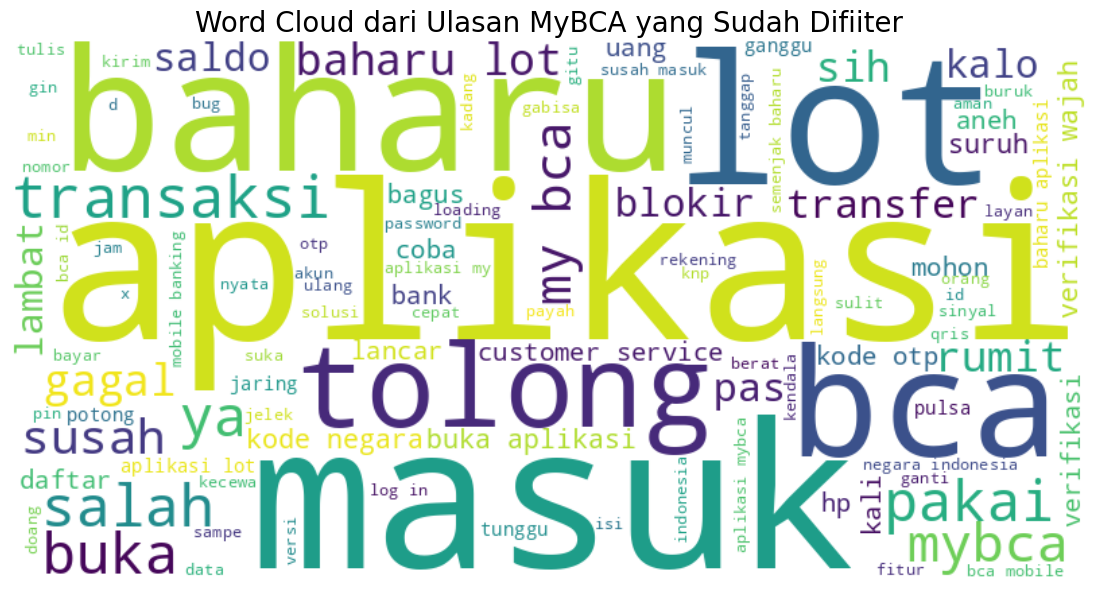

In [ ]:
all_filtered_text = ' '.join(df_github['review_filtered'])

# Buat objek WordCloud
wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white',
                      stopwords=all_stopwords,
                      min_font_size=10).generate(all_filtered_text)

# Tampilkan WordCloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Sembunyikan sumbu
plt.title('Word Cloud dari Ulasan MyBCA yang Sudah Difiiter', fontsize=20)
plt.show()